Setup & Context

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/processed/morocco_master_econometrics.csv')

# Sort time
df = df.sort_values('Year').reset_index(drop=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("📊 Morocco Growth–Jobs Econometric Lab")
print(f"Dataset shape: {df.shape}")
df.head()

📊 Morocco Growth–Jobs Econometric Lab
Dataset shape: (11, 23)


,Year,Y_Total,Y_Primary,Y_Secondary,Y_Tertiary,L_Total,L_Primary,L_Secondary,L_Tertiary,Prod_Total_Scaled,...,Prod_Total_Index,Prod_Primary_Index,Prod_Secondary_Index,Prod_Tertiary_Index,Rel_Prod_Primary,Rel_Prod_Secondary,Rel_Prod_Tertiary,Share_L_Primary,Share_L_Secondary,Share_L_Tertiary
0,2015.0,104.300000,114.000000,101.800000,102.100000,10651654.0,4162470.0,2187965.0,4301219.0,9.791906,...,77.621286,68.089856,96.645574,90.589244,2.796961,4.751603,2.424192,0.390782,0.205411,0.403808
1,2016.0,104.821500,92.796000,103.734200,105.469300,10662327.0,4055740.0,2252003.0,4354584.0,9.831015,...,77.931305,56.883700,95.681409,92.431891,2.327345,4.685486,2.463661,0.380380,0.211211,0.408408
2,2017.0,110.167396,110.891220,107.261163,108.949787,10651654.0,3746223.0,2401425.0,4504006.0,10.342750,...,81.987872,73.592273,92.778648,92.314489,2.861986,4.318545,2.338791,0.351703,0.225451,0.422846
3,2018.0,113.582586,115.881325,110.586259,112.109331,10662327.0,3671512.0,2390752.0,4600063.0,10.652701,...,84.444881,78.468831,96.081816,93.008026,2.962844,4.342171,2.287801,0.344344,0.224224,0.431431
4,2019.0,116.876481,111.361953,115.120295,116.481595,10662327.0,3468725.0,2401425.0,4792177.0,10.961630,...,86.893783,79.817046,99.576632,92.761316,2.928814,4.373285,2.217427,0.325325,0.225225,0.449449


Construct Sectoral Variables

In [15]:
# Sectoral GDP (already exists)
# Y_Primary, Y_Secondary, Y_Tertiary

# Sectoral Employment (already computed)
# L_Primary, L_Secondary, L_Tertiary

# Logs
df['log_Y_Primary'] = np.log(df['Y_Primary'])
df['log_Y_Secondary'] = np.log(df['Y_Secondary'])
df['log_Y_Tertiary'] = np.log(df['Y_Tertiary'])

df['log_L_Primary'] = np.log(df['L_Primary'])
df['log_L_Secondary'] = np.log(df['L_Secondary'])
df['log_L_Tertiary'] = np.log(df['L_Tertiary'])

df.head()

,Year,Y_Total,Y_Primary,Y_Secondary,Y_Tertiary,L_Total,L_Primary,L_Secondary,L_Tertiary,Prod_Total_Scaled,...,Rel_Prod_Tertiary,Share_L_Primary,Share_L_Secondary,Share_L_Tertiary,log_Y_Primary,log_Y_Secondary,log_Y_Tertiary,log_L_Primary,log_L_Secondary,log_L_Tertiary
0,2015.0,104.300000,114.000000,101.800000,102.100000,10651654.0,4162470.0,2187965.0,4301219.0,9.791906,...,2.424192,0.390782,0.205411,0.403808,4.736198,4.623010,4.625953,15.241619,14.598482,15.274409
1,2016.0,104.821500,92.796000,103.734200,105.469300,10662327.0,4055740.0,2252003.0,4354584.0,9.831015,...,2.463661,0.380380,0.211211,0.408408,4.530404,4.641832,4.658420,15.215644,14.627331,15.286740
2,2017.0,110.167396,110.891220,107.261163,108.949787,10651654.0,3746223.0,2401425.0,4504006.0,10.342750,...,2.338791,0.351703,0.225451,0.422846,4.708550,4.675267,4.690887,15.136259,14.691573,15.320478
3,2018.0,113.582586,115.881325,110.586259,112.109331,10662327.0,3671512.0,2390752.0,4600063.0,10.652701,...,2.287801,0.344344,0.224224,0.431431,4.752567,4.705796,4.719475,15.116114,14.687119,15.341581
4,2019.0,116.876481,111.361953,115.120295,116.481595,10662327.0,3468725.0,2401425.0,4792177.0,10.961630,...,2.217427,0.325325,0.225225,0.449449,4.712786,4.745978,4.757733,15.059298,14.691573,15.382495


Growth Rates

In [16]:
# GDP growth by sector
df['dlog_Y_Primary'] = df['log_Y_Primary'].diff()
df['dlog_Y_Secondary'] = df['log_Y_Secondary'].diff()
df['dlog_Y_Tertiary'] = df['log_Y_Tertiary'].diff()

# Employment growth by sector
df['dlog_L_Primary'] = df['log_L_Primary'].diff()
df['dlog_L_Secondary'] = df['log_L_Secondary'].diff()
df['dlog_L_Tertiary'] = df['log_L_Tertiary'].diff()

df[['Year', 'dlog_Y_Primary', 'dlog_L_Primary']].head()

,Year,dlog_Y_Primary,dlog_L_Primary
0,2015.0,NaN,NaN
1,2016.0,-0.205795,-0.025975
2,2017.0,0.178146,-0.079385
3,2018.0,0.044017,-0.020145
4,2019.0,-0.039781,-0.056816


Elasticity Function

In [17]:
def estimate_elasticity(df, y_col, x_col, label):
    data = df[[y_col, x_col]].dropna()

    X = sm.add_constant(data[x_col])
    y = data[y_col]

    model = sm.OLS(y, X).fit()

    beta = model.params[x_col]
    pval = model.pvalues[x_col]

    print(f"\n📌 {label}")
    print("-" * 40)
    print(model.summary())

    return beta, pval

Estimate Sectoral Elasticities

In [18]:
results = {}

results['Primary'] = estimate_elasticity(
    df, 'dlog_L_Primary', 'dlog_Y_Primary', 'Agriculture'
)

results['Secondary'] = estimate_elasticity(
    df, 'dlog_L_Secondary', 'dlog_Y_Secondary', 'Industry'
)

results['Tertiary'] = estimate_elasticity(
    df, 'dlog_L_Tertiary', 'dlog_Y_Tertiary', 'Services'
)


📌 Agriculture
----------------------------------------
                            OLS Regression Results                            
Dep. Variable:         dlog_L_Primary   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.121
Method:                 Least Squares   F-statistic:                   0.02700
Date:                Tue, 05 May 2026   Prob (F-statistic):              0.874
Time:                        22:07:54   Log-Likelihood:                 24.116
No. Observations:                  10   AIC:                            -44.23
Df Residuals:                       8   BIC:                            -43.63
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

Results Summary

In [19]:
summary = pd.DataFrame({
    'Sector': ['Agriculture', 'Industry', 'Services'],
    'Elasticity (β)': [
        results['Primary'][0],
        results['Secondary'][0],
        results['Tertiary'][0]
    ],
    'p-value': [
        results['Primary'][1],
        results['Secondary'][1],
        results['Tertiary'][1]
    ]
})

summary

,Sector,Elasticity (β),p-value
0,Agriculture,0.010945,0.873554
1,Industry,-0.056083,0.774449
2,Services,0.020834,0.850030


Visualization

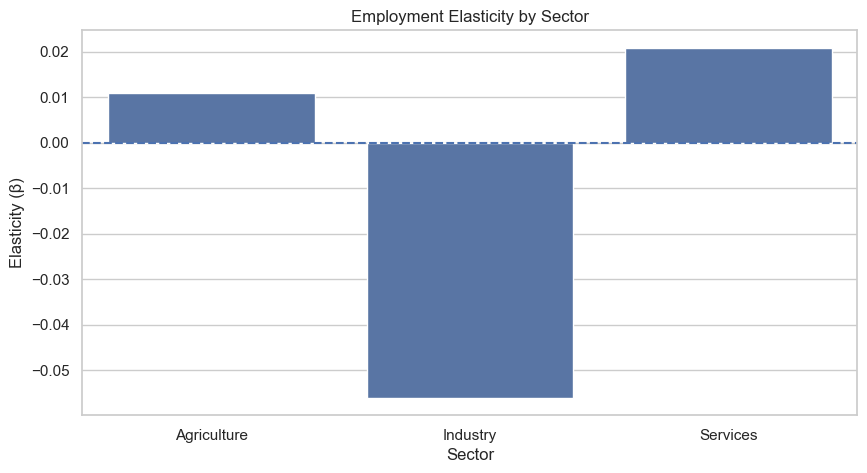

In [20]:
sns.barplot(data=summary, x='Sector', y='Elasticity (β)')

plt.axhline(0, linestyle='--')
plt.title("Employment Elasticity by Sector")
plt.ylabel("Elasticity (β)")

plt.show()

Policy Simulation

In [21]:
# Assume 20% GDP increase
GDP_shock = 0.20

summary['Expected Employment Growth (%)'] = summary['Elasticity (β)'] * GDP_shock * 100

summary

,Sector,Elasticity (β),p-value,Expected Employment Growth (%)
0,Agriculture,0.010945,0.873554,0.218897
1,Industry,-0.056083,0.774449,-1.121660
2,Services,0.020834,0.850030,0.416676
